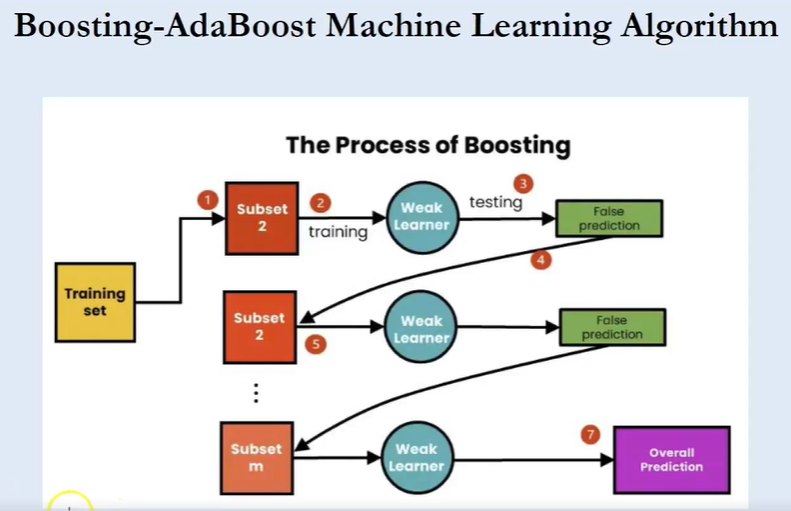

✅ Concept & Introduction

**Definition:**
Boosting is an ensemble technique that builds models sequentially, where each new model focuses on correcting the errors made by the previous ones.

Core Idea:

* Models are trained one after the other.
* Each model learns from the mistakes of the previous.
* Final prediction is a weighted vote (classification) or weighted average (regression).

### Key Use Case:

To reduce bias and build a strong model from many weak learners (usually shallow decision trees).

✅ Characteristics of Boosting

| Feature | Boosting |
| --- | --- |
| **Model sequence** | Trained sequentially |
| **Focus** | Reduce bias |
| **Base learners** | Weak (e.g., shallow trees) |
| **Output Combination** | Weighted vote/average |
| **Overfitting** | Can overfit if not regularized |
| **Performance** | Generally better accuracy than bagging |

✅ Why Use Boosting?

* Captures complex patterns.
* Often outperforms single models and even bagging.
* Great for imbalance classification, credit scoring, fraud detection, etc.

✅ Applications of Boosting

| Domain | Use Case |
| --- | --- |
| **Finance** | Credit scoring, fraud detection |
| **Healthcare** | Predicting disease diagnosis |
| **E-commerce** | Customer churn, recommendation |
| **Insurance** | Claim approval predictions |

🔷 **AdaBoost: Intuition**

✅ **How It Works:**

1. Start with a base model (usually a shallow Decision Tree).
2. Give equal weight to all training samples.
3. After each iteration:
* Increase the weight of **misclassified** samples.
* Decrease the weight of **correctly classified** ones.
4. Train next model on the updated weights.
5. Final prediction: **Weighted vote** of all models.

* Repeat for $n\_estimators$ (e.g., $50$, $100$, etc.)

## Basic Math

At each iteration $m$:

* Misclassified samples get higher weight.
* Each model gets a score $\alpha_m = \ln((1 - \text{error}_m) / \text{error}_m)$
* Final prediction = $\text{sign}(\sum \alpha_m \times h_m(x))$
* **$\text{error}_m$** is the error rate of model $m$ — how often it misclassifies points.
* **$\alpha_m = \ln((1 - \text{error}_m) / \text{error}_m)$** gives more weight to better models (lower error gets higher $\alpha_m$).
* **$h_m(x)$** is the prediction of the $m\text{-th}$ weak learner for input $x$.
* **Final prediction = $\text{sign}(\sum \alpha_m \times h_m(x))$** means we take a weighted...
sum of predictions and use the **sign function** to decide the final class: $+1$ or $-1$.

---

## 6.2 Python Implementation using Scikit-learn

## 🧪 Predicting Wine Quality using AdaBoost Classifier 🍷

A Boosting-based ML approach to classify high-quality wine from physicochemical properties



In [2]:
 # 📌 Step 1: Import Required Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

# 📌 Step 2: Load the Dataset (assumes ';' separated CSV)
df = pd.read_csv("winequality-red (1).csv", sep=';')

In [4]:
# step 3 : Create Binary target Column
# lets treat wine with quality >=7 as "good" (1), Others as "not good"(0)
df['target'] = df['quality'].apply(lambda x:1 if x>=7 else 0)

In [5]:
print ("Befor SMOTE:\n", df['target'].value_counts())

Befor SMOTE:
 target
0    1382
1     217
Name: count, dtype: int64


In [6]:
#step 5: Define Features and Target 
x= df.drop(['quality', 'target'], axis = 1)
y=df['target']

In [7]:
# step 6 = Apply SMOTE to balence classes
smote = SMOTE(random_state = 42)
x_balance, y_balance = smote.fit_resample(x,y)

In [8]:
print("\n After SMOTE:\n", y_balance.value_counts())


 After SMOTE:
 target
0    1382
1    1382
Name: count, dtype: int64


In [10]:
x_train, x_test, y_train, y_test = train_test_split(
    x_balance, y_balance, test_size = 0.2, random_state= 42, stratify=y_balance
)

In [11]:
# 📌 Step 8: Initialize Base Estimator (Weak Learner)

# In AdaBoost, we start with a very simple model - often called a "weak learner".

# Here, we're using a decision stump (a tree with max_depth = 1) which makes simple yes/no splits.

base_estimator = DecisionTreeClassifier(max_depth=1)

In [13]:
# 📌 Step 9: Initialize AdaBoost Classifier

# AdaBoost works by combining several weak learners to create a strong classifier.

ada_model = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

# - n_estimators = 50 means we will train 50 weak learners sequentially.
# - learning_rate controls how much each weak learner contributes (default is 1.0).
# - base_estimator is the simple model we defined above.

In [14]:
ada_model.fit(x_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...r(max_depth=1)
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](50,)","[0.23,0.32,0.37,...,0.47,0.45,0.48]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](50,)","[1.23,0.73,0.55,...,0.11,0.22,0.07]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419), DecisionTreeC...te=1935803228), DecisionTreeC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](11,)","[0.02,0.15,0.04,...,0.02,0.13,0.34]"


In [15]:
y_pred = ada_model.predict(x_test)

In [16]:
print("\n Classification Report:")
print(classification_report(y_test, y_pred))


 Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       277
           1       0.85      0.84      0.84       276

    accuracy                           0.85       553
   macro avg       0.85      0.85      0.85       553
weighted avg       0.85      0.85      0.85       553



In [17]:
print("Accuracy score:", accuracy_score(y_test, y_pred))

Accuracy score: 0.8462929475587704



📊 Confusion Matrix:


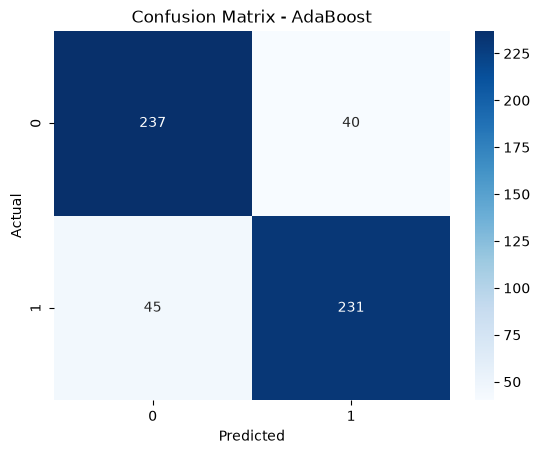

In [18]:
print("\n📊 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - AdaBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
#OBSERVATION:
# AdaBoost improves performance by focusing more on misclassified examples.